In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))

import os
from src.datasets.biosignal_dataset import BioSignalDataset

In [2]:
split_data_dir = r'/path/to/split_data/alcohol'
# split_data_dir = r'../data/split_data/alcohol'
subject_list = os.listdir(split_data_dir)

In [3]:
alcohol_data = BioSignalDataset(split_data_dir, 'ECG', 'PPG', 'GSR')

## Raw Data Load

In [4]:
raw_data_dict = alcohol_data.get_raw_data(load_pkl=r'../save/raw_data.pkl', save_pkl=r'../save/raw_data.pkl')
# raw_data_dict = alcohol_data.get_raw_data(save_pkl=r'../save/raw_data.pkl')

## Data Preprocessing

In [5]:
preprocessed_data_dict = alcohol_data.get_preprocessed_data(load_pkl=r'../save/preprocessed_data.pkl', save_pkl=r'../save/preprocessed_data.pkl')
# preprocessed_data_dict = alcohol_data.get_preprocessed_data(save_pkl=r'../save/preprocessed_data.pkl')

## Feature Extraction

In [6]:
features = alcohol_data.get_features(load_pkl=r'../save/features.pkl', save_pkl=r'../save/features.pkl')
# features = alcohol_data.get_features(save_pkl=r'../save/features.pkl')

## Label Load

In [7]:
labels = alcohol_data.get_labels(r"../data/labels/alcohol.json")

## Plot Signal

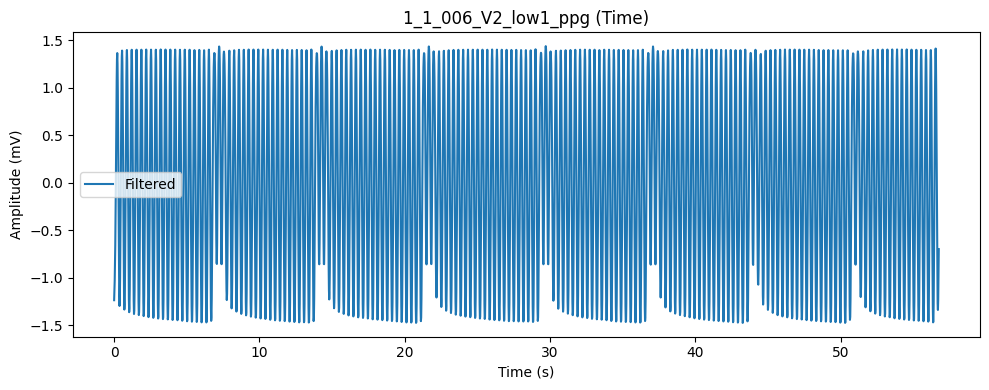

In [8]:
alcohol_data.show_plot(subject_name='1_1_006', session_id='V2', trial_id='low1', sig_type='PPG', channel='ppg', fs=51.2, unit='mV', type='time')

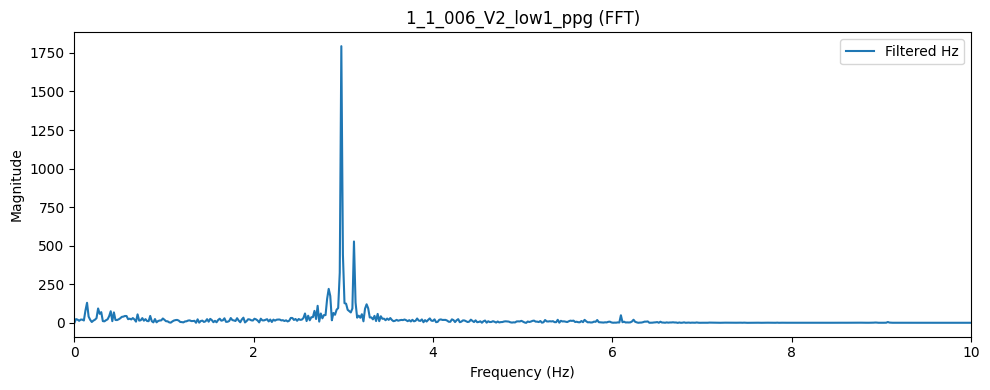

In [9]:
alcohol_data.show_plot(subject_name='1_1_006', session_id='V2', trial_id='low1', sig_type='PPG', channel='ppg', fs=51.2, unit='mV', type='frequency')

# 누락 모달리티 확인

## 1. GSR

In [10]:
import numpy as np

gsr_mean_amplitude = {}
for subj_id, sessions in alcohol_data.raw_data.items():
    gsr_mean_amplitude[subj_id] = {}

    for sess_id, trials in sessions.items():
        gsr_mean_amplitude[subj_id][sess_id] = {}
        means = []
        for trial_id, trial_dict in trials.items():
            
            means.append(np.mean(trial_dict['GSR']['gsr']))
        
        min_val = np.min(np.array(means))
        mean_val = np.mean(np.array(means))
        gsr_mean_amplitude[subj_id][sess_id]['min'] = min_val
        gsr_mean_amplitude[subj_id][sess_id]['mean'] = mean_val

In [11]:
GSR_abnormal_sessions = [
    '1_1_002_V1', '1_1_002_V2', '1_1_005_V1', '1_1_005_V2', '1_1_006_V2', '1_1_007_V2', '1_1_008_V1', '1_1_008_V2', '1_1_010_V1', '1_1_010_V2',
    '1_1_011_V1', '1_1_012_V1', '1_1_012_V2', '1_1_013_V1', '1_1_013_V2', '1_1_014_V1', '1_1_014_V2', '1_1_015_V1', '1_1_015_V2', '1_1_016_V1', 
    '1_1_016_V2', '1_1_017_V1', '1_1_017_V2', '1_1_018_V1', '1_1_019_V1', '1_1_019_V2', '1_1_020_V1', '1_1_020_V2', '1_1_024_V1', '1_1_025_V2',
    '1_1_029_V1', '1_1_029_V2', '1_1_031_V2', '1_1_032_V2', '1_1_033_V2', '1_1_035_V1', '1_1_035_V2', '1_1_038_V1', '1_1_038_V2', '1_2_005_V1', 
    '1_2_005_V2', '1_2_006_V1', '1_2_006_V2', '1_2_008_V2', '1_2_009_V1', '1_2_009_V2', '1_2_010_V1', '1_2_010_V2', '1_2_011_V2', '1_2_012_V1', 
    '1_2_012_V2', '1_2_013_V1', '1_2_013_V2'
   ]    # GSR abnormal 53 sessions

results = []

for subj_id, sessions in gsr_mean_amplitude.items():
    for sess_id, trials in sessions.items():
        key = f"{subj_id}_{sess_id}"
        min_val = trials['min']
        mean_val = trials['mean']
        results.append((key, min_val, mean_val))

# min 값 기준으로 오름차순 정렬
results_sorted = sorted(results, key=lambda x: x[1])

# 출력
for key, val1, val2 in results_sorted:
    print(key, f"{val1:.4f}", f"{val2:.4f}", key in GSR_abnormal_sessions)


1_1_002_V1 0.0522 0.0545 True
1_1_016_V2 0.0579 0.0642 True
1_1_002_V2 0.0708 0.0728 True
1_1_018_V2 0.0887 0.1081 False
1_1_035_V2 0.0942 0.1006 True
1_1_016_V1 0.0955 0.1010 True
1_1_005_V1 0.1103 0.1168 True
1_1_035_V1 0.1109 0.1275 True
1_1_020_V2 0.1144 0.1262 True
1_1_024_V1 0.1305 0.1581 True
1_1_032_V2 0.1337 0.1438 True
1_1_032_V1 0.1357 0.1469 False
1_1_017_V2 0.1534 0.1581 True
1_1_013_V2 0.1701 0.1976 True
1_1_017_V1 0.1722 0.1872 True
1_2_005_V2 0.1768 0.1829 True
1_1_024_V2 0.1781 0.1910 False
1_2_013_V1 0.1823 0.1861 True
1_1_029_V1 0.1840 0.2332 True
1_1_030_V1 0.1905 0.2140 False
1_1_013_V1 0.1909 0.2362 True
1_1_031_V2 0.1910 0.2180 True
1_2_013_V2 0.2103 0.2241 True
1_1_040_V2 0.2122 0.4220 False
1_2_006_V2 0.2146 0.2236 True
1_2_005_V1 0.2158 0.2292 True
1_1_031_V1 0.2234 0.2298 False
1_1_005_V2 0.2372 0.2524 True
1_1_038_V2 0.2374 0.2763 True
1_1_037_V1 0.2644 0.2994 False
1_1_008_V2 0.2692 0.2958 True
1_1_010_V2 0.2807 0.3098 True
1_1_011_V1 0.2933 0.3048 True
1_1

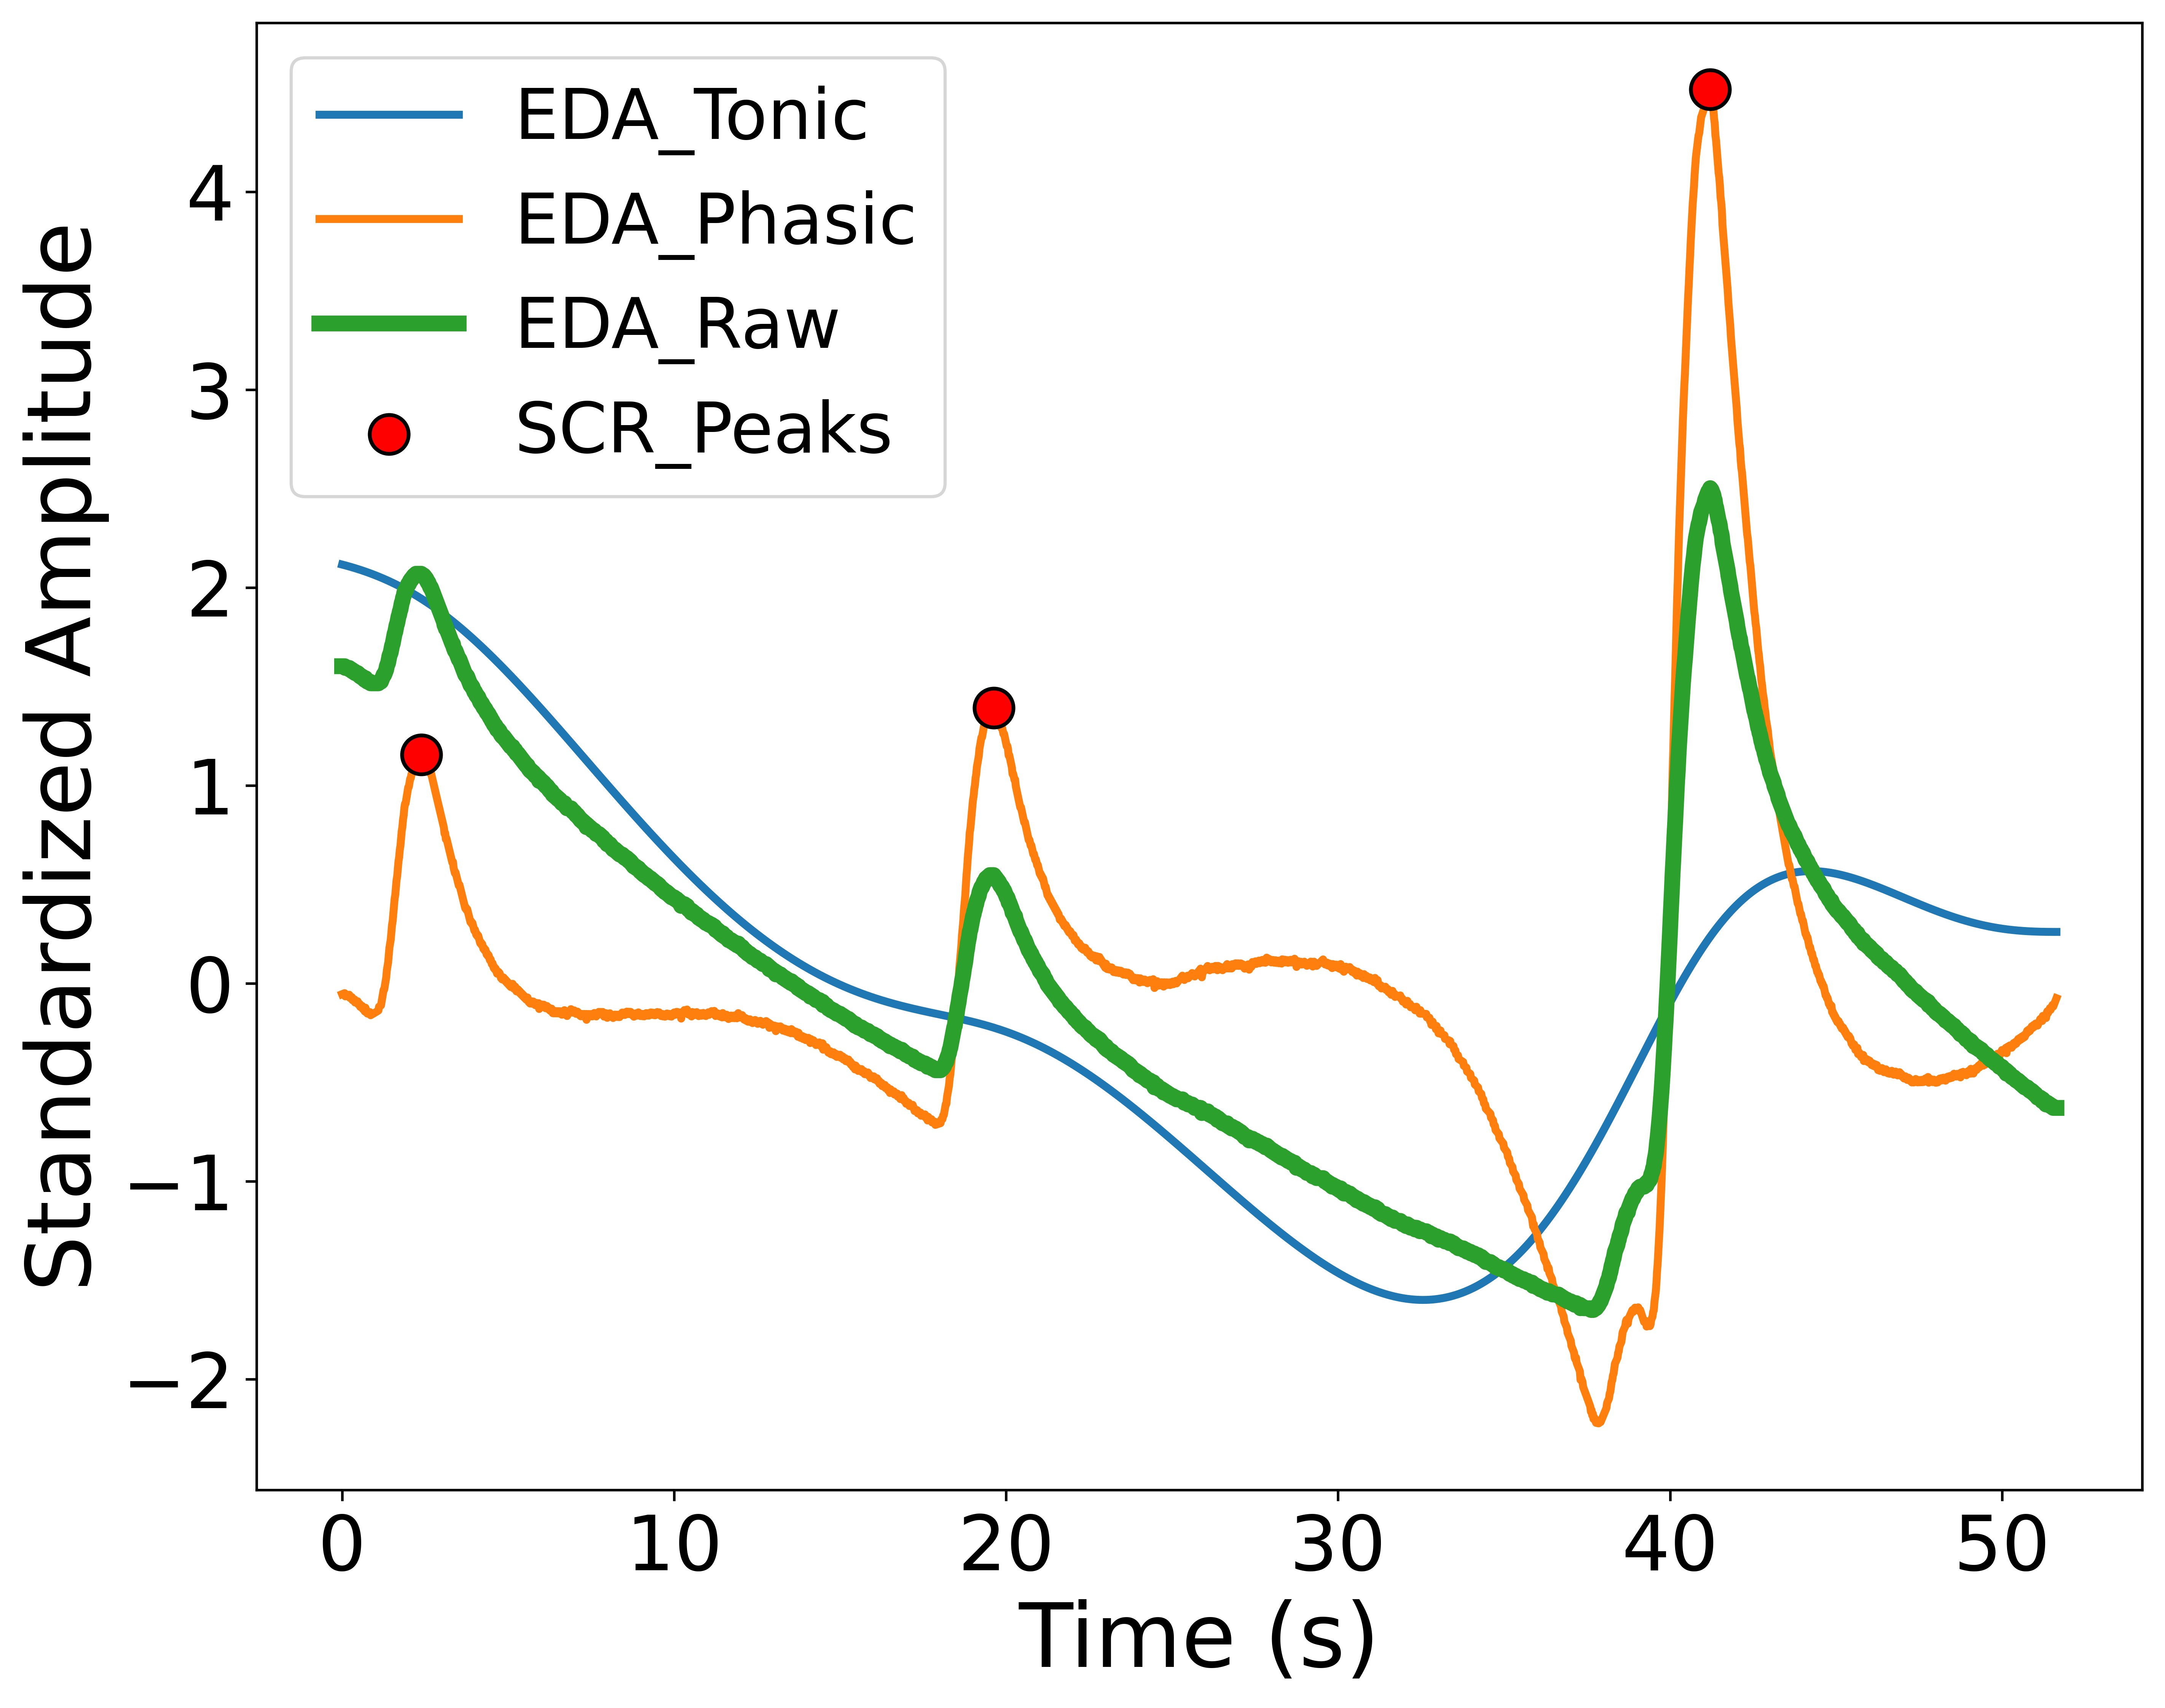

In [12]:
import neurokit2 as nk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fs = 51.2

eda_signal = alcohol_data.raw_data["1_1_003"]["V1"]["low5"]["GSR"]["gsr"]

# 기존처럼 phasic decomposition
data = nk.eda_phasic(nk.standardize(eda_signal), sampling_rate=fs)
data["EDA_Raw"] = eda_signal

# SCR peak 검출
peak_signals, info = nk.eda_peaks(
    data["EDA_Phasic"],
    sampling_rate=fs,
    amplitude_min=0.05
)

# peak index
peak_idx = np.where(peak_signals["SCR_Peaks"].values == 1)[0]

# 기존 그림 느낌 유지하려고 표준화해서 직접 그림
plot_df = pd.DataFrame({
    "EDA_Tonic": nk.standardize(data["EDA_Tonic"]),
    "EDA_Phasic": nk.standardize(data["EDA_Phasic"]),
    "EDA_Raw": nk.standardize(data["EDA_Raw"]),
})

# 시간축 생성
time = np.arange(len(plot_df)) / fs

# 폰트/해상도 크게
plt.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 600,
    "font.size": 24,
    "axes.titlesize": 22,
    "axes.labelsize": 28,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "legend.fontsize": 22,
    "legend.title_fontsize": 17,
})

plt.figure(figsize=(10, 8), dpi=600)

plt.plot(time, plot_df["EDA_Tonic"], label="EDA_Tonic", linewidth=2.5)
plt.plot(time, plot_df["EDA_Phasic"], label="EDA_Phasic", linewidth=2.5)
plt.plot(time, plot_df["EDA_Raw"], label="EDA_Raw", linewidth=5)

# peak만 표시
plt.scatter(
    time[peak_idx],
    plot_df["EDA_Phasic"].iloc[peak_idx],
    label="SCR_Peaks",
    s=150,
    zorder=5,
    facecolor="red",
    edgecolor="black",
    linewidth=1.2,
)

plt.xlabel("Time (s)")
plt.ylabel("Standardized Amplitude")

# x축 tick 간격 설정 (예: 10초 간격)
plt.xticks(np.arange(0, time[-1] + 1, 10))

plt.legend(loc="best", frameon=True)
plt.tight_layout()


# 저장까지 하려면
plt.savefig("eda_scr_peaks.png", bbox_inches="tight", dpi=600)
plt.show()

## 2. ECG, PPG

In [13]:
df_wide = alcohol_data.get_feature_table_wide('HR')
df_wide

,subject,session,trial,ECG__HR,PPG__HR
0,1_1_001,V1,high1_w000,119.930346,108.634877
1,1_1_001,V1,high1_w001,129.075310,104.788915
2,1_1_001,V1,high1_w002,131.389242,91.840069
3,1_1_001,V1,high1_w003,130.436747,106.146530
4,1_1_001,V1,high1_w004,130.538838,107.748360
...,...,...,...,...,...
15111,1_2_013,V2,start1_w005,67.477981,67.243808
15112,1_2_013,V2,start1_w006,70.056080,69.754299
15113,1_2_013,V2,start1_w007,70.612067,70.314437
15114,1_2_013,V2,start1_w008,68.815456,68.576886


In [14]:
df_wide["ecg_ppg_diff"] = (df_wide["ECG__HR"] - df_wide["PPG__HR"]).abs()

df_wide["flag_ecg_ppg_mismatch"] = df_wide["ecg_ppg_diff"] > 5

def decide_hr_quality(row):
    if row["ecg_ppg_diff"] > 5:
        return "BAD"
    else:
        return "GOOD"

df_wide["hr_quality"] = df_wide.apply(decide_hr_quality, axis=1)

In [15]:
df_bad = df_wide[df_wide["hr_quality"] == "BAD"]
df_bad

,subject,session,trial,ECG__HR,PPG__HR,ecg_ppg_diff,flag_ecg_ppg_mismatch,hr_quality
0,1_1_001,V1,high1_w000,119.930346,108.634877,11.295469,True,BAD
1,1_1_001,V1,high1_w001,129.075310,104.788915,24.286395,True,BAD
2,1_1_001,V1,high1_w002,131.389242,91.840069,39.549174,True,BAD
3,1_1_001,V1,high1_w003,130.436747,106.146530,24.290217,True,BAD
4,1_1_001,V1,high1_w004,130.538838,107.748360,22.790478,True,BAD
...,...,...,...,...,...,...,...,...
14331,1_2_011,V1,low5_w001,96.812807,82.645124,14.167683,True,BAD
14615,1_2_012,V1,high7_w001,93.813418,87.584500,6.228918,True,BAD
14729,1_2_012,V2,high1_w006,85.603765,80.459836,5.143929,True,BAD
14730,1_2_012,V2,high1_w007,90.050229,84.878462,5.171767,True,BAD


In [16]:
import numpy as np
import pandas as pd

def summarize_bad_by_subject_session(
    df_wide: pd.DataFrame,
    ecg_range_th: float = 5.0,
    ecg_std_th: float = 2.0,
    ecg_ppg_diff_th: float = 5.0,
    decision_col: str = "hr_quality",   # "GOOD/BAD"
):
    df = df_wide.copy()

    if "ecg_hr_range" not in df.columns:
        df["ecg_hr_range"] = 0.0

    if "ecg_hr_std" not in df.columns:
        df["ecg_hr_std"] = 0.0

    if "ecg_hr_median" not in df.columns:
        df["ecg_hr_median"] = df["ECG__HR"] if "ECG__HR" in df.columns else np.nan

    if "ecg_ppg_diff" not in df.columns:
        if "ECG__HR" in df.columns and "PPG__HR" in df.columns:
            df["ecg_ppg_diff"] = (df["ECG__HR"] - df["PPG__HR"]).abs()
        else:
            df["ecg_ppg_diff"] = np.nan

    # --- 이유 flag ---
    df["reason_ecg_inconsistent"] = (df["ecg_hr_range"] > ecg_range_th) | (df["ecg_hr_std"] > ecg_std_th)
    df["reason_ecg_ppg_mismatch"] = df["ecg_ppg_diff"] > ecg_ppg_diff_th

    # --- BAD 정의 ---
    if decision_col in df.columns:
        df["is_bad"] = df[decision_col].astype(str).str.upper().eq("BAD")
    else:
        # decision_col 없으면: 이유 flag 중 하나라도 True면 BAD로 간주(원하면 수정)
        df["is_bad"] = df["reason_ecg_inconsistent"] | df["reason_ecg_ppg_mismatch"]

    # --- reason 텍스트(겹치면 둘다 표시) ---
    def _reason_text(r):
        a = bool(r["reason_ecg_inconsistent"])
        b = bool(r["reason_ecg_ppg_mismatch"])
        if a and b: return "ECG_inconsistent+ECG-PPG_mismatch"
        if a: return "ECG_inconsistent"
        if b: return "ECG-PPG_mismatch"
        return "NA"

    df["bad_reason"] = np.where(df["is_bad"], df.apply(_reason_text, axis=1), "NA")

    # --- subject/session 요약 ---
    grp = ["subject", "session"]
    summary = (
        df.groupby(grp)
          .agg(
              n_total=("trial", "nunique"),
              n_bad=("is_bad", "sum"),
              bad_rate=("is_bad", "mean"),
              n_ecg_inconsistent=("reason_ecg_inconsistent", lambda x: int(np.sum(x & df.loc[x.index, "is_bad"]))),
              n_ecg_ppg_mismatch=("reason_ecg_ppg_mismatch", lambda x: int(np.sum(x & df.loc[x.index, "is_bad"]))),
              n_both=("bad_reason", lambda s: int((s == "ECG_inconsistent+ECG-PPG_mismatch").sum())),
          )
          .reset_index()
    )

    summary["bad_rate"] = (summary["bad_rate"] * 100).round(1)

    # 보기 좋게 정렬: bad 많은 순 -> 비율 높은 순
    summary = summary.sort_values(["n_bad", "bad_rate"], ascending=[False, False]).reset_index(drop=True)

    # --- (옵션) BAD trial 리스트(사유 포함) ---
    bad_trials = (
        df[df["is_bad"]]
        .loc[:, ["subject", "session", "trial", "bad_reason", "ecg_hr_range", "ecg_hr_std", "ecg_ppg_diff"]]
        .sort_values(["subject", "session", "trial"])
        .reset_index(drop=True)
    )

    return summary, bad_trials, df


# 사용 예시
summary, bad_trials, df_with_reasons = summarize_bad_by_subject_session(
    df_wide,
    ecg_range_th=5,
    ecg_std_th=2,
    ecg_ppg_diff_th=5,
    decision_col="hr_quality",
)

summary

,subject,session,n_total,n_bad,bad_rate,n_ecg_inconsistent,n_ecg_ppg_mismatch,n_both
0,1_1_001,V2,157,130,82.8,0,130,0
1,1_1_006,V2,124,124,100.0,0,124,0
2,1_1_001,V1,100,86,86.0,0,86,0
3,1_1_016,V2,157,78,49.7,0,78,0
4,1_1_004,V2,157,62,39.5,0,62,0
...,...,...,...,...,...,...,...,...
95,1_1_040,V2,157,0,0.0,0,0,0
96,1_2_001,V1,155,0,0.0,0,0,0
97,1_2_005,V1,157,0,0.0,0,0,0
98,1_2_011,V2,155,0,0.0,0,0,0


In [17]:
df_bad[(df_bad['subject'] == '1_1_034') & (df_bad['session']=='V2')]

,subject,session,trial,ECG__HR,PPG__HR,ecg_ppg_diff,flag_ecg_ppg_mismatch,hr_quality
9674,1_1_034,V2,end1_w001,103.240759,87.045411,16.195348,True,BAD
9675,1_1_034,V2,end1_w002,116.769488,84.786132,31.983357,True,BAD
9676,1_1_034,V2,end1_w003,101.102639,85.549095,15.553544,True,BAD
9678,1_1_034,V2,end1_w005,113.635472,87.563605,26.071867,True,BAD
9679,1_1_034,V2,end1_w006,120.204270,88.021614,32.182656,True,BAD
9680,1_1_034,V2,end1_w007,110.505830,87.181954,23.323876,True,BAD
9682,1_1_034,V2,end1_w009,105.991152,88.842980,17.148172,True,BAD
9690,1_1_034,V2,high2_w002,91.884445,84.748477,7.135968,True,BAD
9691,1_1_034,V2,high2_w003,102.897471,85.739073,17.158397,True,BAD
9692,1_1_034,V2,high2_w004,105.759618,85.222527,20.537091,True,BAD


## Abnormal signal session results

In [18]:
sampling_rate_error = {"1_1_030_V1", "1_1_031_V1", "1_1_032_V1", "1_1_033_V1"}
missing_LA_RA = {"1_1_009_V1", "1_1_023_V2", "1_1_034_V1", "1_1_034_V2"}
missing_LL_LA = {"1_1_022_V2", "1_1_034_V1", "1_1_034_V2"}
missing_LL_RA = {}
missing_Vx_RL = {"1_2_013_V1"}
missing_PPG = {"1_1_001_V1", "1_1_001_V2", "1_1_006_V2", "1_1_009_V1", "1_1_009_V2", "1_1_016_V2"}
missing_GSR = {
    "1_1_002_V1", "1_1_002_V2", "1_1_005_V1", "1_1_005_V2", "1_1_010_V1",
    "1_1_011_V1", "1_1_012_V2", "1_1_013_V2", "1_1_016_V1", "1_1_016_V2",
    "1_1_017_V1", "1_1_017_V2", "1_1_018_V2", "1_1_019_V1", "1_1_020_V2",
    "1_1_024_V1", "1_1_024_V2", "1_1_025_V2", "1_1_027_V2", "1_1_029_V1",
    "1_1_029_V2", "1_1_032_V2", "1_1_035_V1", "1_1_035_V2", "1_1_037_V1",
    "1_2_002_V2", "1_2_005_V1", "1_2_005_V2", "1_2_006_V1", "1_2_006_V2",
    "1_2_008_V2", "1_2_009_V1", "1_2_013_V1"
}

In [19]:
def _safe_zscore(x):
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)
    if (not np.isfinite(sd)) or sd < 1e-12:
        return np.zeros_like(x, dtype=float)
    return (x - mu) / sd


def _status_color(status):
    status = str(status).lower()
    if status == "valid":
        return "green"
    elif "multi" in status:
        return "orange"
    elif "zero" in status:
        return "red"
    else:
        return "gray"


def _prepare_ptt_case_view(
    row,
    dataset_obj,
    window_sec=10.0,
    overlap_ratio=0.5,
    view_start_sec=3.0,
    view_end_sec=8.0,
    fusion_cluster_ms=100.0,
    fusion_min_agree_leads=2,
    fusion_outlier_ms=40.0,
    correct_artifacts_per_lead=True,
    post_fix_fused_peaks=True,
    fused_fix_method="Kubios",
    ppg_method="elgendi",
    post_fix_ppg_peaks=True,
    ppg_fix_method="Kubios",
    resample_method="cubic",
):
    subject = str(row["subject"])
    session = str(row["session"])
    trial = str(row["trial"])
    window = str(row["window"])

    if subject not in dataset_obj.preprocessed_data:
        raise ValueError(f"subject not found: {subject}")
    if session not in dataset_obj.preprocessed_data[subject]:
        raise ValueError(f"session not found: {subject} {session}")
    if trial not in dataset_obj.preprocessed_data[subject][session]:
        raise ValueError(f"trial not found: {subject} {session} {trial}")

    trial_dict = dataset_obj.preprocessed_data[subject][session][trial]

    # 기존처럼 window 복원
    windowed_trial = _extract_window_from_preprocessed_trial(
        trial_dict,
        window_id=window,
        window_sec=window_sec,
        overlap_ratio=overlap_ratio,
    )

    if windowed_trial is None or "ECG" not in windowed_trial or "PPG" not in windowed_trial:
        raise ValueError(f"cannot reconstruct window: {subject} {session} {trial} {window}")

    # 기존 peak 계산 경로 그대로 사용
    pack = _recompute_ptt_path_exactly_like_csv(
        windowed_trial=windowed_trial,
        fusion_cluster_ms=fusion_cluster_ms,
        fusion_min_agree_leads=fusion_min_agree_leads,
        fusion_outlier_ms=fusion_outlier_ms,
        correct_artifacts_per_lead=correct_artifacts_per_lead,
        post_fix_fused_peaks=post_fix_fused_peaks,
        fused_fix_method=fused_fix_method,
        ppg_method=ppg_method,
        post_fix_ppg_peaks=post_fix_ppg_peaks,
        ppg_fix_method=ppg_fix_method,
        resample_method=resample_method,
    )

    ecg_lead = pack["ecg_lead"]
    ecg_sig = np.asarray(pack["ecg_sig"], dtype=float)
    ppg_sig = np.asarray(pack["ppg_sig"], dtype=float)
    fused_idx = np.asarray(pack["fused_idx"], dtype=int)
    ppg_idx = np.asarray(pack["ppg_idx"], dtype=int)
    t_abs = np.asarray(pack["t_abs"], dtype=float)
    t_rel = np.asarray(pack["t_rel"], dtype=float)

    # CSV 저장값 -> 현재 window 기준 상대시간
    r0_abs = float(row["r0_sec"])
    r1_abs = float(row["r1_sec"])
    lo_abs = float(row["win_lo_sec"])
    hi_abs = float(row["win_hi_sec"])
    sel_abs = float(row["selected_ppg_peak_sec"]) if pd.notna(row["selected_ppg_peak_sec"]) else np.nan

    r0_rel = r0_abs - t_abs[0]
    r1_rel = r1_abs - t_abs[0]
    lo_rel = lo_abs - t_abs[0]
    hi_rel = hi_abs - t_abs[0]
    sel_rel = sel_abs - t_abs[0] if np.isfinite(sel_abs) else np.nan

    # 사용자가 원하는 보기 구간
    view_start_sec = max(float(view_start_sec), float(t_rel.min()))
    view_end_sec = min(float(view_end_sec), float(t_rel.max()))
    if view_end_sec <= view_start_sec:
        raise ValueError(f"invalid view range: {view_start_sec} - {view_end_sec}")

    crop_mask = (t_rel >= view_start_sec) & (t_rel <= view_end_sec)
    if crop_mask.sum() < 5:
        raise ValueError("cropped segment is too short")

    crop_global_idx = np.where(crop_mask)[0]

    # global index -> crop local index 매핑
    global_to_local = -np.ones(len(t_rel), dtype=int)
    global_to_local[crop_global_idx] = np.arange(len(crop_global_idx))

    # crop 후 다시 z-score normalization
    t_crop = t_rel[crop_mask]
    ecg_crop = _safe_zscore(ecg_sig[crop_mask])
    ppg_crop = _safe_zscore(ppg_sig[crop_mask])

    fused_local = global_to_local[fused_idx]
    fused_local = fused_local[fused_local >= 0]

    ppg_local = global_to_local[ppg_idx]
    ppg_local = ppg_local[ppg_local >= 0]

    # pairing window 내부 candidate peaks
    candidate_global = ppg_idx[(t_rel[ppg_idx] >= lo_rel) & (t_rel[ppg_idx] <= hi_rel)]
    candidate_local = global_to_local[candidate_global]
    candidate_local = candidate_local[candidate_local >= 0]

    # selected peak
    selected_local = None
    if np.isfinite(sel_rel):
        sel_global = int(np.argmin(np.abs(t_rel - sel_rel)))
        if 0 <= sel_global < len(global_to_local):
            sel_local = global_to_local[sel_global]
            if sel_local >= 0:
                selected_local = int(sel_local)

    status = str(row["status"]) if "status" in row.index else "unknown"
    n_candidates = int(len(candidate_global))
    ptt_ms_str = _format_optional(row["ptt_ms"], ".1f")
    rr_sec_str = _format_optional(row["rr_sec"], ".3f")

    return {
        "subject": subject,
        "session": session,
        "trial": trial,
        "window": window,
        "beat_idx": int(row["beat_idx"]) if pd.notna(row["beat_idx"]) else -1,
        "status": status,
        "n_candidates": n_candidates,
        "ptt_ms_str": ptt_ms_str,
        "rr_sec_str": rr_sec_str,
        "ecg_lead": ecg_lead,
        "t_crop": t_crop,
        "ecg_crop": ecg_crop,
        "ppg_crop": ppg_crop,
        "fused_local": fused_local,
        "ppg_local": ppg_local,
        "candidate_local": candidate_local,
        "selected_local": selected_local,
        "view_start_sec": view_start_sec,
        "view_end_sec": view_end_sec,
        "r0_rel": r0_rel,
        "r1_rel": r1_rel,
        "lo_rel": lo_rel,
        "hi_rel": hi_rel,
        "sel_rel": sel_rel,
    }


def _draw_case_on_axes(ax_ecg, ax_ppg, case, title_prefix=""):
    t = case["t_crop"]
    ecg = case["ecg_crop"]
    ppg = case["ppg_crop"]

    # -------- ECG --------
    ax_ecg.plot(t, ecg, linewidth=1.2, label="ECG (crop-zscore)")
    if len(case["fused_local"]) > 0:
        ax_ecg.scatter(
            t[case["fused_local"]],
            ecg[case["fused_local"]],
            s=28,
            marker="o",
            label="Fused R-peaks"
        )

    if case["view_start_sec"] <= case["r0_rel"] <= case["view_end_sec"]:
        ax_ecg.axvline(case["r0_rel"], linestyle="--", linewidth=1.2, label="r0")
    if case["view_start_sec"] <= case["r1_rel"] <= case["view_end_sec"]:
        ax_ecg.axvline(case["r1_rel"], linestyle="--", linewidth=1.2, label="r1")

    span_lo = max(case["lo_rel"], case["view_start_sec"])
    span_hi = min(case["hi_rel"], case["view_end_sec"])
    if span_hi > span_lo:
        ax_ecg.axvspan(span_lo, span_hi, alpha=0.18, label="Valid pairing window")

    ax_ecg.set_ylabel(f"ECG ({case['ecg_lead']})")
    ax_ecg.legend(loc="upper right", fontsize=8)

    ax_ecg.set_title(
        f"{title_prefix}"
        f"{case['subject']} {case['session']} | {case['trial']} | {case['window']} | "
        f"beat={case['beat_idx']} | status={case['status']} | "
        f"n_cand={case['n_candidates']} | PTT={case['ptt_ms_str']} ms | RR={case['rr_sec_str']} s",
        fontsize=11
    )

    # -------- PPG --------
    ax_ppg.plot(t, ppg, linewidth=1.2, label="PPG (crop-zscore)")

    if len(case["ppg_local"]) > 0:
        ax_ppg.scatter(
            t[case["ppg_local"]],
            ppg[case["ppg_local"]],
            s=22,
            marker="o",
            alpha=0.55,
            label="All PPG peaks"
        )

    if len(case["candidate_local"]) > 0:
        ax_ppg.scatter(
            t[case["candidate_local"]],
            ppg[case["candidate_local"]],
            s=55,
            marker="o",
            label=f"Candidate peaks in valid window ({case['n_candidates']})"
        )

    if case["selected_local"] is not None:
        ax_ppg.scatter(
            [t[case["selected_local"]]],
            [ppg[case["selected_local"]]],
            s=120,
            marker="*",
            label="Selected PPG peak"
        )

    if case["view_start_sec"] <= case["r0_rel"] <= case["view_end_sec"]:
        ax_ppg.axvline(case["r0_rel"], linestyle="--", linewidth=1.2, label="r0")
    if case["view_start_sec"] <= case["r1_rel"] <= case["view_end_sec"]:
        ax_ppg.axvline(case["r1_rel"], linestyle="--", linewidth=1.2, label="r1")

    if span_hi > span_lo:
        ax_ppg.axvspan(span_lo, span_hi, alpha=0.18, label="Valid pairing window")

    ax_ppg.set_xlabel("Time in window (s)")
    ax_ppg.set_ylabel("PPG")
    ax_ppg.legend(loc="upper right", fontsize=8)


def plot_ptt_valid_invalid_comparison(
    valid_row,
    invalid_row,
    dataset_obj,
    out_path,
    window_sec=10.0,
    overlap_ratio=0.5,
    view_start_sec=3.0,
    view_end_sec=8.0,
    fusion_cluster_ms=100.0,
    fusion_min_agree_leads=2,
    fusion_outlier_ms=40.0,
    correct_artifacts_per_lead=True,
    post_fix_fused_peaks=True,
    fused_fix_method="Kubios",
    ppg_method="elgendi",
    post_fix_ppg_peaks=True,
    ppg_fix_method="Kubios",
    resample_method="cubic",
):
    valid_case = _prepare_ptt_case_view(
        row=valid_row,
        dataset_obj=dataset_obj,
        window_sec=window_sec,
        overlap_ratio=overlap_ratio,
        view_start_sec=view_start_sec,
        view_end_sec=view_end_sec,
        fusion_cluster_ms=fusion_cluster_ms,
        fusion_min_agree_leads=fusion_min_agree_leads,
        fusion_outlier_ms=fusion_outlier_ms,
        correct_artifacts_per_lead=correct_artifacts_per_lead,
        post_fix_fused_peaks=post_fix_fused_peaks,
        fused_fix_method=fused_fix_method,
        ppg_method=ppg_method,
        post_fix_ppg_peaks=post_fix_ppg_peaks,
        ppg_fix_method=ppg_fix_method,
        resample_method=resample_method,
    )

    invalid_case = _prepare_ptt_case_view(
        row=invalid_row,
        dataset_obj=dataset_obj,
        window_sec=window_sec,
        overlap_ratio=overlap_ratio,
        view_start_sec=view_start_sec,
        view_end_sec=view_end_sec,
        fusion_cluster_ms=fusion_cluster_ms,
        fusion_min_agree_leads=fusion_min_agree_leads,
        fusion_outlier_ms=fusion_outlier_ms,
        correct_artifacts_per_lead=correct_artifacts_per_lead,
        post_fix_fused_peaks=post_fix_fused_peaks,
        fused_fix_method=fused_fix_method,
        ppg_method=ppg_method,
        post_fix_ppg_peaks=post_fix_ppg_peaks,
        ppg_fix_method=ppg_fix_method,
        resample_method=resample_method,
    )

    Path(out_path).parent.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=False, dpi=250)

    _draw_case_on_axes(
        axes[0, 0], axes[0, 1],
        valid_case,
        title_prefix="[VALID] "
    )
    _draw_case_on_axes(
        axes[1, 0], axes[1, 1],
        invalid_case,
        title_prefix="[INVALID] "
    )

    fig.suptitle(
        f"PTT pairing comparison | crop={view_start_sec:.1f}-{view_end_sec:.1f} s",
        fontsize=14,
        y=0.995
    )

    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight")
    plt.close()

    print(f"saved: {out_path}")

def _nearest_peak_index_from_time(t_rel, peak_idx, target_t):
    peak_idx = np.asarray(peak_idx, dtype=int)
    if len(peak_idx) == 0 or (not np.isfinite(target_t)):
        return None
    return int(peak_idx[np.argmin(np.abs(t_rel[peak_idx] - target_t))])

COLORS = {
    "ecg": "#0072B2",         # blue
    "ppg": "#E69F00",         # orange
    "ptt": "#009E73",         # green
    "rpeak": "#111111",       # near black
    "systolic": "#CC79A7",    # magenta
    "valid_fill": "#BFE7C6",  # soft green
    "multi_fill": "#F3D19C",  # soft orange
    "zero_fill": "#E8B4B8",   # soft pink-red
    "other_fill": "#D9D9D9",  # gray
}






def _status_color(status):
    status = str(status).lower()
    if status == "valid":
        return COLORS["valid_fill"]
    elif "multi" in status:
        return COLORS["multi_fill"]
    elif "zero" in status:
        return COLORS["zero_fill"]
    else:
        return COLORS["other_fill"]



def plot_ptt_mixed_in_one_signal(
    dataset_obj,
    csv_path,
    subject,
    session,
    trial,
    window,
    out_path,
    view_start_sec=3.0,
    view_end_sec=8.0,
    window_sec=10.0,
    overlap_ratio=0.5,
    fusion_cluster_ms=100.0,
    fusion_min_agree_leads=2,
    fusion_outlier_ms=40.0,
    correct_artifacts_per_lead=True,
    post_fix_fused_peaks=True,
    fused_fix_method="Kubios",
    ppg_method="elgendi",
    post_fix_ppg_peaks=True,
    ppg_fix_method="Kubios",
    resample_method="cubic",
    ecg_offset=2.0,
    ppg_offset=-2.0,
):

    """
    하나의 signal segment 안에서 ECG/PPG를 한 plot에 겹쳐 그리고,
    beat별 valid / invalid pairing window를 동시에 표시.
    """

    # --------------------------------------------------
    # 1) CSV에서 해당 signal의 beat rows 불러오기
    # --------------------------------------------------
    df_ptt = pd.read_csv(csv_path)

    rows_sig = df_ptt[
        (df_ptt["subject"].astype(str) == str(subject)) &
        (df_ptt["session"].astype(str) == str(session)) &
        (df_ptt["trial"].astype(str) == str(trial)) &
        (df_ptt["window"].astype(str) == str(window))
    ].copy()

    if len(rows_sig) == 0:
        print("해당 signal/window에 대한 row가 없습니다.")
        return None

    rows_sig = rows_sig.sort_values(["beat_idx"]).reset_index(drop=True)

    # --------------------------------------------------
    # 2) dataset_obj에서 trial 불러오고 해당 window 복원
    # --------------------------------------------------
    if str(subject) not in dataset_obj.preprocessed_data:
        print(f"subject not found: {subject}")
        return None
    if str(session) not in dataset_obj.preprocessed_data[str(subject)]:
        print(f"session not found: {subject} {session}")
        return None
    if str(trial) not in dataset_obj.preprocessed_data[str(subject)][str(session)]:
        print(f"trial not found: {subject} {session} {trial}")
        return None

    trial_dict = dataset_obj.preprocessed_data[str(subject)][str(session)][str(trial)]

    windowed_trial = _extract_window_from_preprocessed_trial(
        trial_dict,
        window_id=str(window),
        window_sec=window_sec,
        overlap_ratio=overlap_ratio,
    )

    if windowed_trial is None or "ECG" not in windowed_trial or "PPG" not in windowed_trial:
        print("window reconstruction failed")
        return None

    # --------------------------------------------------
    # 3) 기존 방식대로 ECG/PPG peak 재계산
    # --------------------------------------------------
    try:
        pack = _recompute_ptt_path_exactly_like_csv(
            windowed_trial=windowed_trial,
            fusion_cluster_ms=fusion_cluster_ms,
            fusion_min_agree_leads=fusion_min_agree_leads,
            fusion_outlier_ms=fusion_outlier_ms,
            correct_artifacts_per_lead=correct_artifacts_per_lead,
            post_fix_fused_peaks=post_fix_fused_peaks,
            fused_fix_method=fused_fix_method,
            ppg_method=ppg_method,
            post_fix_ppg_peaks=post_fix_ppg_peaks,
            ppg_fix_method=ppg_fix_method,
            resample_method=resample_method,
        )
    except Exception as e:
        print(f"recompute failed: {e}")
        return None

    ecg_lead = pack["ecg_lead"]
    ecg_sig = np.asarray(pack["ecg_sig"], dtype=float)
    ppg_sig = np.asarray(pack["ppg_sig"], dtype=float)
    fused_idx = np.asarray(pack["fused_idx"], dtype=int)
    ppg_idx = np.asarray(pack["ppg_idx"], dtype=int)
    t_abs = np.asarray(pack["t_abs"], dtype=float)
    t_rel = np.asarray(pack["t_rel"], dtype=float)

    # --------------------------------------------------
    # 4) crop
    # --------------------------------------------------
    view_start_sec = max(float(view_start_sec), float(t_rel.min()))
    view_end_sec = min(float(view_end_sec), float(t_rel.max()))
    if view_end_sec <= view_start_sec:
        print("invalid crop range")
        return None

    crop_mask = (t_rel >= view_start_sec) & (t_rel <= view_end_sec)
    if crop_mask.sum() < 5:
        print("cropped segment too short")
        return None

    crop_global_idx = np.where(crop_mask)[0]

    global_to_local = -np.ones(len(t_rel), dtype=int)
    global_to_local[crop_global_idx] = np.arange(len(crop_global_idx))

    t_crop = t_rel[crop_mask]

    # crop 후 다시 z-score normalization
    ecg_crop = _safe_zscore(ecg_sig[crop_mask])
    ppg_crop = _safe_zscore(ppg_sig[crop_mask])

    # 겹쳐 그릴 때 보기 좋게 offset
    ecg_plot = ecg_crop + ecg_offset
    ppg_plot = ppg_crop + ppg_offset

    fused_local = global_to_local[fused_idx]
    fused_local = fused_local[fused_local >= 0]

    ppg_local = global_to_local[ppg_idx]
    ppg_local = ppg_local[ppg_local >= 0]

    # --------------------------------------------------
    # 5) plot
    # --------------------------------------------------
    plt.rcParams.update({
        "figure.dpi": 180,
        "savefig.dpi": 600,
        "font.size": 24,
        "axes.titlesize": 22,
        "axes.labelsize": 28,
        "xtick.labelsize": 24,
        "ytick.labelsize": 24,
        "legend.fontsize": 22,
        "legend.title_fontsize": 17,
    })
    plt.figure(figsize=(10, 8), dpi=600)
    ax = plt.gca()

    # background: beat별 window / valid-invalid 표시
    beat_summaries = []

    for _, row in rows_sig.iterrows():
        status = str(row["status"]) if "status" in row.index else "unknown"
        color = _status_color(status)

        lo_abs = float(row["win_lo_sec"])
        hi_abs = float(row["win_hi_sec"])
        r0_abs = float(row["r0_sec"])
        r1_abs = float(row["r1_sec"])

        lo_rel = lo_abs - t_abs[0]
        hi_rel = hi_abs - t_abs[0]
        r0_rel = r0_abs - t_abs[0]
        r1_rel = r1_abs - t_abs[0]

        # crop 구간과 겹치는 beat만 plot
        if hi_rel < view_start_sec or lo_rel > view_end_sec:
            continue

        span_lo = max(lo_rel, view_start_sec)
        span_hi = min(hi_rel, view_end_sec)

        # valid window 배경 표시
        ax.axvspan(span_lo, span_hi, color=color, alpha=0.4)

        # r0, r1 표시
        if view_start_sec <= r0_rel <= view_end_sec:
            ax.axvline(r0_rel, color=color, linestyle="--", linewidth=1.0, alpha=1)
        if view_start_sec <= r1_rel <= view_end_sec:
            ax.axvline(r1_rel, color=color, linestyle=":", linewidth=1.0, alpha=1)

        # 이 beat의 candidate PPG peaks
        cand_global = ppg_idx[(t_rel[ppg_idx] >= lo_rel) & (t_rel[ppg_idx] <= hi_rel)]
        cand_local = global_to_local[cand_global]
        cand_local = cand_local[cand_local >= 0]

        # valid beat면 ECG R-peak <-> selected PPG peak 연결
        if (
            status.lower() == "valid"
            and "selected_ppg_peak_sec" in row.index
            and pd.notna(row["selected_ppg_peak_sec"])
        ):
            sel_abs = float(row["selected_ppg_peak_sec"])
            sel_rel = sel_abs - t_abs[0]

            # selected peak의 global/local index
            sel_global = int(np.argmin(np.abs(t_rel - sel_rel)))
            sel_local = global_to_local[sel_global] if 0 <= sel_global < len(global_to_local) else -1

            # 해당 beat의 r0에 가장 가까운 fused R-peak 찾기
            r0_peak_global = _nearest_peak_index_from_time(t_rel, fused_idx, r0_rel)
            r0_peak_local = (
                global_to_local[r0_peak_global]
                if (r0_peak_global is not None and 0 <= r0_peak_global < len(global_to_local))
                else -1
            )

            # crop 안에 둘 다 있으면 연결선 그리기
            if (sel_local >= 0) and (r0_peak_local >= 0):
                ax.plot(
                    [t_crop[r0_peak_local], t_crop[sel_local]],
                    [ecg_plot[r0_peak_local], ppg_plot[sel_local]],
                    color=COLORS["ptt"],
                    linestyle="--",
                    linewidth=3,
                    alpha=0.95,
                    zorder=4
                )

                # # selected PPG peak도 다시 강조
                # ax.scatter(
                #     [t_crop[sel_local]],
                #     [ppg_plot[sel_local]],
                #     s=180,
                #     marker="*",
                #     color="green",
                #     edgecolor="black",
                #     linewidth=1.0,
                #     zorder=8
                # )

                # midpoint에 PTT 표시하고 싶으면
                # mid_x = 0.5 * (t_crop[r0_peak_local] + t_crop[sel_local])
                # mid_y = 0.5 * (ecg_plot[r0_peak_local] + ppg_plot[sel_local])
                # ax.text(
                #     mid_x,
                #     mid_y,
                #     f"{float(row['ptt_ms']):.0f} ms",
                #     color="black",
                #     fontsize=12,
                #     ha="left",
                #     va="bottom",
                #     zorder=5
                # )
        
        if len(cand_local) > 0:
            ax.scatter(
                t_crop[cand_local],
                ppg_plot[cand_local],
                s=65,
                color=color,
                edgecolor="black",
                zorder=5
            )

        # # selected peak 표시 (있으면)
        # if "selected_ppg_peak_sec" in row.index and pd.notna(row["selected_ppg_peak_sec"]):
        #     sel_abs = float(row["selected_ppg_peak_sec"])
        #     sel_rel = sel_abs - t_abs[0]
        #     if view_start_sec <= sel_rel <= view_end_sec:
        #         sel_global = int(np.argmin(np.abs(t_rel - sel_rel)))
        #         sel_local = global_to_local[sel_global]
        #         if sel_local >= 0:
        #             ax.scatter(
        #                 [t_crop[sel_local]],
        #                 [ppg_plot[sel_local]],
        #                 s=160,
        #                 # marker="*",
        #                 color=color,
        #                 edgecolor="black",
        #                 zorder=6
        #             )

        beat_summaries.append(
            f"b{int(row['beat_idx'])}:{status}({len(cand_global)})"
        )

    # ECG / PPG signal
    ax.plot(t_crop, ecg_plot, linewidth=2, color=COLORS["ecg"], label="ECG")
    ax.plot(t_crop, ppg_plot, linewidth=2, color=COLORS["ppg"], label="PPG")

    # ECG fused R-peaks
    if len(fused_local) > 0:
        ax.scatter(
            t_crop[fused_local],
            ecg_plot[fused_local],
            s=100,
            color=COLORS["rpeak"],
            marker="o",
            label="R-peaks",
            zorder=5
        )

    # all PPG peaks
    if len(ppg_local) > 0:
        ax.scatter(
            t_crop[ppg_local],
            ppg_plot[ppg_local],
            s=100,
            color=COLORS["systolic"],
            marker="o",
            label="Systolic peaks",
            zorder=6
        )

    # 보조선
    ax.axhline(ecg_offset, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axhline(ppg_offset, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)

    ax.set_xlim(view_start_sec, view_end_sec)
    # ax.set_xlabel("Time in window (s)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Standardized Amplitude + Offset")

    # title = (
    #     f"{subject} {session} | {trial} | {window} | crop={view_start_sec:.1f}-{view_end_sec:.1f}s\n"
    #     f"ECG+PPG overlay | beat status(count) = " + ", ".join(beat_summaries[:10])
    # )
    # ax.set_title(title, fontsize=12)

    # custom legend
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    handles = [
        Line2D([0], [0], color=COLORS["ecg"], lw=2, label="ECG"),
        Line2D([0], [0], color=COLORS["ppg"], lw=2, label="PPG"),
        Line2D([0], [0], color=COLORS["ptt"], lw=3, linestyle="--", label="Valid PTT pair"),
        Line2D([0], [0], marker="o", color=COLORS["rpeak"], linestyle="None", label="R-peaks"),
        Line2D([0], [0], marker="o", color=COLORS["systolic"], linestyle="None", label="Systolic peaks"),
    ]
    ax.legend(handles=handles, loc="best", fontsize=22)

    plt.tight_layout()
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, bbox_inches="tight")
    plt.close()

    print(f"saved: {out_path}")
    return rows_sig

def _extract_window_from_preprocessed_trial(trial_dict, window_id, window_sec=10.0, overlap_ratio=0.5):
    if "_w" not in window_id:
        return trial_dict

    win_idx = int(window_id.split("_w")[-1])
    win_ms = int(window_sec * 1000)
    step_ms = int(win_ms * (1.0 - overlap_ratio))

    t_start = float("inf")
    t_end = float("-inf")
    for sig_type in ["ECG", "PPG", "GSR"]:
        if sig_type in trial_dict and "timestamp" in trial_dict[sig_type]:
            ts = np.asarray(trial_dict[sig_type]["timestamp"])
            if len(ts) > 0:
                t_start = min(t_start, ts[0])
                t_end = max(t_end, ts[-1])

    if not np.isfinite(t_start):
        return None

    current_start = t_start + win_idx * step_ms
    current_end = current_start + win_ms

    windowed_trial = {}
    for sig_type in ["ECG", "PPG", "GSR"]:
        if sig_type not in trial_dict or "timestamp" not in trial_dict[sig_type]:
            continue

        ts = np.asarray(trial_dict[sig_type]["timestamp"])
        mask = (ts >= current_start) & (ts < current_end)
        if np.sum(mask) == 0:
            continue

        windowed_trial[sig_type] = {}
        for ch, val in trial_dict[sig_type].items():
            windowed_trial[sig_type][ch] = np.asarray(val)[mask]

    return windowed_trial

def _choose_ecg_lead(ecg_dict):
    for ch in ["LL_RA", "LA_RA", "LL_LA",  "Vx_RL"]:
        if ch in ecg_dict:
            return ch
    others = [k for k in ecg_dict.keys() if k != "timestamp"]
    if len(others) == 0:
        raise ValueError("No ECG lead found.")
    return others[0]


def _recompute_ptt_path_exactly_like_csv(
    windowed_trial,
    fusion_cluster_ms=100.0,
    fusion_min_agree_leads=2,
    fusion_outlier_ms=40.0,
    correct_artifacts_per_lead=True,
    post_fix_fused_peaks=True,
    fused_fix_method="Kubios",
    ppg_method="elgendi",
    post_fix_ppg_peaks=True,
    ppg_fix_method="Kubios",
    resample_method="cubic",
):
    """
    현재 get_ECG_PPG_PTT() fused mode와 같은 경로로
    synced ECG/PPG, fused ECG peaks, PPG peaks를 다시 계산
    """
    ecg = windowed_trial["ECG"]
    ppg = windowed_trial["PPG"]

    ecg_time_ms = np.asarray(ecg["timestamp"])
    ppg_time_ms = np.asarray(ppg["timestamp"])

    df_ppg_raw = pd.DataFrame({
        "Timestamp": pd.to_datetime(ppg_time_ms, unit="ms"),
        "PPG": np.asarray(ppg["ppg"], dtype=float),
    }).set_index("Timestamp").sort_index()

    df_ecg_base = pd.DataFrame({
        "Timestamp": pd.to_datetime(ecg_time_ms, unit="ms"),
    }).set_index("Timestamp").sort_index()

    # ECG timestamp 기준으로 PPG align
    df_synced = pd.concat([df_ecg_base, df_ppg_raw], axis=1).sort_index()
    if resample_method == "cubic":
        df_synced["PPG"] = df_synced["PPG"].interpolate(method="cubic")
    else:
        df_synced["PPG"] = df_synced["PPG"].interpolate(method="time")

    df_synced = df_synced.loc[df_ecg_base.index].dropna(subset=["PPG"])
    if df_synced.empty:
        raise ValueError("df_synced is empty")

    valid_mask = df_ecg_base.index.isin(df_synced.index)

    # synced grid에서 fs 계산
    dt = df_synced.index.to_series().diff().median().total_seconds()
    fs = 1.0 / dt if dt and dt > 0 else np.nan
    if not np.isfinite(fs) or fs <= 0:
        raise ValueError("Invalid synced fs")

    # per-lead ECG peak detection on masked ECG
    per_lead_info = {}
    signal_length = len(df_synced)

    for ch_name, sig in ecg.items():
        if ch_name == "timestamp":
            continue

        ch_sig = np.asarray(sig, dtype=float)[valid_mask]

        try:
            _, info = nk.ecg_peaks(
                ch_sig,
                sampling_rate=fs,
                correct_artifacts=correct_artifacts_per_lead,
                show=False,
            )
            per_lead_info[ch_name] = info
        except Exception:
            per_lead_info[ch_name] = None

    # ECG fuse
    _, fused_info = _fuse_multilead_rpeaks_from_info(
        info_dict=per_lead_info,
        signal_length=signal_length,
        fs_ecg=fs,
        cluster_ms=fusion_cluster_ms,
        min_agree_leads=fusion_min_agree_leads,
        outlier_ms=fusion_outlier_ms,
    )

    fused_idx = np.asarray(fused_info.get("ECG_R_Peaks", []), dtype=int)

    fused_artifacts = {}
    if post_fix_fused_peaks and len(fused_idx) >= 3:
        fused_idx, fused_artifacts = _post_fix_fused_rpeaks(
            fused_idx,
            fs_ecg=fs,
            method=fused_fix_method,
            iterative=True,
            show=False,
        )

    fused_idx = np.asarray(fused_idx, dtype=int)
    fused_idx = fused_idx[(fused_idx >= 0) & (fused_idx < len(df_synced))]

    # PPG peaks on synced PPG
    _, ppg_info = nk.ppg_peaks(
        df_synced["PPG"].to_numpy(),
        sampling_rate=fs,
        method=ppg_method,
        correct_artifacts=True,
        show=False,
    )
    ppg_idx = np.asarray(ppg_info.get("PPG_Peaks", []), dtype=int)

    ppg_artifacts = {}
    if post_fix_ppg_peaks and len(ppg_idx) >= 3:
        ppg_idx, ppg_artifacts = _post_fix_peak_indices(
            ppg_idx,
            fs=fs,
            method=ppg_fix_method,
            iterative=True,
            show=False,
        )

    ppg_idx = np.asarray(ppg_idx, dtype=int)
    ppg_idx = ppg_idx[(ppg_idx >= 0) & (ppg_idx < len(df_synced))]

    # one ECG lead for visualization, same masked space
    ecg_lead = _choose_ecg_lead(ecg)
    ecg_sig = np.asarray(ecg[ecg_lead], dtype=float)[valid_mask]
    ppg_sig = df_synced["PPG"].to_numpy()

    # absolute / relative time
    t_abs = df_synced.index.astype("int64").to_numpy() / 1e9
    t_rel = t_abs - t_abs[0]

    return {
        "df_synced": df_synced,
        "fs": fs,
        "ecg_lead": "LA_RL",
        "ecg_sig": ecg_sig,
        "ppg_sig": ppg_sig,
        "fused_idx": fused_idx,
        "ppg_idx": ppg_idx,
        "t_abs": t_abs,
        "t_rel": t_rel,
        "fused_artifacts": fused_artifacts,
        "ppg_artifacts": ppg_artifacts,
    }



In [20]:
plot_ptt_mixed_in_one_signal(
    dataset_obj=alcohol_data,
    csv_path="../runs/07_final_report/all_raw_ptt_data_05_70_3.csv",
    subject="1_1_024", session="V1", trial="high5", window="high5_w005"

    ,
    out_path="../runs/07_final_report/ptt_mixed_one_signal_1.png",
    view_start_sec=4.5,
    view_end_sec=9.5,
)

recompute failed: name '_fuse_multilead_rpeaks_from_info' is not defined


In [21]:
plot_ptt_mixed_in_one_signal(
    dataset_obj=alcohol_data,
    csv_path="../runs/07_final_report/all_raw_ptt_data_05_70_3.csv",
    subject="1_1_005", session="V1", trial="mid6", window="mid6_w000"
    ,
    out_path="../runs/07_final_report/ptt_mixed_one_signal_2.png",
    view_start_sec=0,
    view_end_sec=10,
)

recompute failed: name '_fuse_multilead_rpeaks_from_info' is not defined


In [22]:
plot_ptt_mixed_in_one_signal(
    dataset_obj=alcohol_data,
    csv_path="../runs/07_final_report/all_raw_ptt_data_05_70_3.csv",
    subject="1_1_035", session="V2", trial="high2", window="high2_w007"


    ,
    out_path="../runs/07_final_report/ptt_mixed_one_signal_3.png",
    view_start_sec=0,
    view_end_sec=10,
)

recompute failed: name '_fuse_multilead_rpeaks_from_info' is not defined


In [23]:
plot_ptt_mixed_in_one_signal(
    dataset_obj=alcohol_data,
    csv_path="../runs/07_final_report/all_raw_ptt_data_05_70_3.csv",
    subject="1_1_016", session="V1", trial="mid4", window="mid4_w001"


    ,
    out_path="../runs/07_final_report/ptt_mixed_one_signal_4.png",
    view_start_sec=5,
    view_end_sec=10,
)

recompute failed: name '_fuse_multilead_rpeaks_from_info' is not defined
